In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import itertools

import tslearn

import pycatch22

from sklearn.preprocessing import StandardScaler
import umap

import warnings
#warnings.filterwarnings("ignore")

SEED = 42

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load dataset

In [2]:
from tslearn.datasets import UCR_UEA_datasets
# Load the LSST dataset from UEA archive
ds = UCR_UEA_datasets()
X_train, y_train, X_test, y_test = ds.load_dataset("LSST")

In [3]:
X_train

array([[[ 1.7597e+01,  8.1713e+00, -1.7842e+00, -1.9706e+01,
         -9.7135e+00, -6.1887e+01],
        [ 2.2974e-01, -5.8956e+00,  1.6837e+01,  5.0390e+00,
          2.4332e+00,  5.8914e+01],
        [-2.9654e+01, -2.1296e+01,  2.9103e+01, -4.7503e-01,
          7.5391e+01,  1.0665e+01],
        ...,
        [ 1.1982e+02,  2.1849e+02,  1.6398e+03,  5.9787e+02,
          2.1922e+03,  1.8484e+01],
        [ 9.1591e+01,  1.0378e+02,  1.8238e+03,  1.2460e+03,
          1.1301e+04,  7.5107e+02],
        [ 4.3719e+01,  3.0689e+01,  9.5092e+02,  8.5927e+02,
          8.1331e+03,  9.8883e+02]],

       [[ 2.4209e+00, -5.6039e-01,  2.3654e+01, -3.8171e+00,
          1.3721e+00,  8.2510e+00],
        [ 1.6847e+00,  2.3989e+01,  1.7803e+01, -1.9575e+01,
         -8.2534e+00, -2.3959e+01],
        [ 5.0692e-01,  5.0281e+01,  5.1196e+01,  1.6036e+01,
          7.2974e-01, -1.8185e+01],
        ...,
        [-1.5618e+01, -7.4233e+00,  3.7833e+00,  1.6565e+00,
         -1.0438e+01, -5.5229e+00],
  

In [4]:
y_train

array(['6', '6', '6', ..., '95', '95', '95'], dtype='<U2')

In [5]:
n_samples, n_steps, n_channel = X_train.shape

df_X_train = pd.DataFrame(
    X_train.reshape(n_samples * n_steps, n_channel),
    columns=[f"X_{i}" for i in range(n_channel)],
    index=pd.MultiIndex.from_product(
        [range(n_samples), range(n_steps)],
        names=["Sample", "timestamp"]
    )
)
df_X_train

X_0       X_1       X_2       X_3       X_4      X_5
Sample timestamp                                                           
0      0          17.59700   8.17130  -1.78420 -19.70600  -9.71350 -61.8870
       1           0.22974  -5.89560  16.83700   5.03900   2.43320  58.9140
       2         -29.65400 -21.29600  29.10300  -0.47503  75.39100  10.6650
       3         -59.21000 -29.56500  17.97100 -45.60600  19.41200 -43.0140
       4         -72.06400 -25.85500   0.46536 -59.15100 -29.10500 -11.9130
...                    ...       ...       ...       ...       ...      ...
2458   31          3.51190  -1.03240  -1.69900   4.15790   2.75430   5.9823
       32          0.70853  -0.94622  -1.91760   2.09480  -4.76750   7.4118
       33          0.20638   1.02870  -0.92512  -0.71633   1.73330   4.7638
       34          4.14290   1.09390  -0.18921   1.14100   0.93441   4.1742
       35         -1.55450  -1.21210   1.07050   1.32720   2.40100   8.4550

[88524 rows x 6 columns]

In [6]:
def tweak_and_convert_y(y):
    return (
        pd.DataFrame(
            y,
            columns=["target"],
            index=pd.RangeIndex(len(y), name="Sample")
        )
        .astype("category")
    )
df_y_train = tweak_and_convert_y(y_train)
df_y_train

,target
Sample,
0,6
1,6
2,6
3,6
4,6
...,...
2454,95
2455,95
2456,95


# Stat Des

In [7]:
df_X_train.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 88524 entries, (0, 0) to (2458, 35)
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X_0     88524 non-null  float64
 1   X_1     88524 non-null  float64
 2   X_2     88524 non-null  float64
 3   X_3     88524 non-null  float64
 4   X_4     88524 non-null  float64
 5   X_5     88524 non-null  float64
dtypes: float64(6)
memory usage: 4.4 MB


In [8]:
df_X_train.isna().sum().sum()

0

In [9]:
df_X_train.describe()

,X_0,X_1,X_2,X_3,X_4,X_5
count,88524.000000,88524.000000,88524.000000,88524.000000,88524.000000,88524.000000
mean,9.457359,18.967527,28.007991,38.972271,50.137320,55.647919
std,248.783134,780.927607,714.910750,846.073292,1116.893019,1427.121411
min,-3420.000000,-11585.000000,-10289.000000,-8009.900000,-19855.000000,-40036.000000
25%,-3.632475,-1.706950,-1.729300,-2.506775,-4.151025,-8.605200
50%,0.272985,0.410845,0.648295,0.941070,1.282150,2.115450
75%,5.604900,4.093025,6.869375,9.903500,14.078000,20.841250
max,32932.000000,44394.000000,37032.000000,48133.000000,60249.000000,64062.000000


In [10]:
df_y_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2459 entries, 0 to 2458
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   target  2459 non-null   category
dtypes: category(1)
memory usage: 3.2 KB


In [11]:
df_y_train.describe()

,target
count,2459
unique,14
top,90
freq,777


<Axes: xlabel='target'>

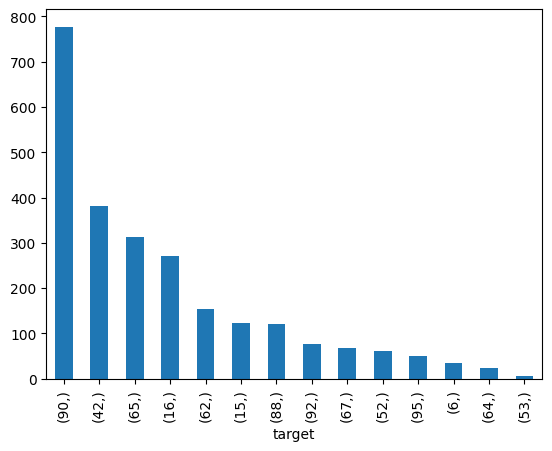

In [12]:
df_y_train.value_counts().plot.bar()

Class are heavily imbalanced $\to$ accuracy may not be the best metric...

<Axes: xlabel='target'>

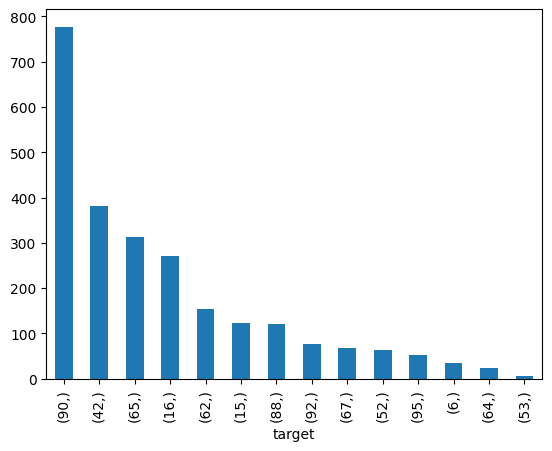

In [13]:
tweak_and_convert_y(y_test).value_counts().plot.bar()

Problem persists in the test...

Ideas of other metrcis : wieghted accuracy, F1-score (multi-class version) ?  
cf. white paper ([METRICS FOR MULTI-CLASS CLASSIFICATION: AN OVERVIEW](https://arxiv.org/pdf/2008.05756))

# Baseline 1

## Catch22 + logit reg

In [14]:
tsData_as_numpy = np.array([1, 2, 3, 4])
results_numpy = pycatch22.catch22_all(tsData_as_numpy)
for feature, output in zip(results_numpy['names'], results_numpy['values']):
    print(f"{feature}: {output}")

DN_HistogramMode_5: 0.0
DN_HistogramMode_10: 0.0
CO_f1ecac: 0.8428274117714277
CO_FirstMin_ac: 4
CO_HistogramAMI_even_2_5: 0.6931471805599453
CO_trev_1_num: 0.46475800154489005
MD_hrv_classic_pnn40: 1.0
SB_BinaryStats_mean_longstretch1: 1.0
SB_TransitionMatrix_3ac_sumdiagcov: 0.3333333333333333
PD_PeriodicityWang_th0_01: 0
CO_Embed2_Dist_tau_d_expfit_meandiff: 0.0
IN_AutoMutualInfoStats_40_gaussian_fmmi: 2.0
FC_LocalSimple_mean1_tauresrat: 0.0
DN_OutlierInclude_p_001_mdrmd: 0.75
DN_OutlierInclude_n_001_mdrmd: -0.25
SP_Summaries_welch_rect_area_5_1: 0.0
SB_BinaryStats_diff_longstretch0: 1.0
SB_MotifThree_quantile_hh: 1.0986122886681096
SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1: 0.0
SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1: 0.0
SP_Summaries_welch_rect_centroid: 1.570796326795
FC_LocalSimple_mean3_stderr: nan


Pb : the library forces you to compute the feature in a univariate framework so channel by channel.  
It is not a pb in itself if we plug a head model that is going to learn the interaction (random forest for example, but we clearly limit the perf with logit reg) and also because it is what PatchTST do so......

In [15]:
X_train.shape

(2459, 36, 6)

In [16]:
def compute_catch22_features(X):
    n_samples, n_steps, n_channel = X.shape
    X_train_features = []
    for i in range(n_samples):
        features_sample = []
        for channel in range(n_channel):
            ts = X[i, :, channel]
            features_channel = pycatch22.catch22_all(ts)
            features_sample += features_channel["values"] 
        features_sample = np.array(features_sample)
        X_train_features.append(features_sample)

    X_train_features = np.array(X_train_features)
    X_train_features = (
        pd.DataFrame(
            X_train_features,
            columns=[f"{name}_{i}" for name, i in itertools.product(
                range(n_channel), 
                features_channel['names'])],
            index=pd.RangeIndex(n_samples, name="Sample")
        )
    )
    return X_train_features

X_train_features = compute_catch22_features(X_train)

In [17]:
scale = StandardScaler()
X_train_features_scaled = scale.fit_transform(X_train_features)

projection_viz = umap.UMAP(n_components=2, random_state=SEED)

low_dim_viz = projection_viz.fit_transform(X_train_features_scaled)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


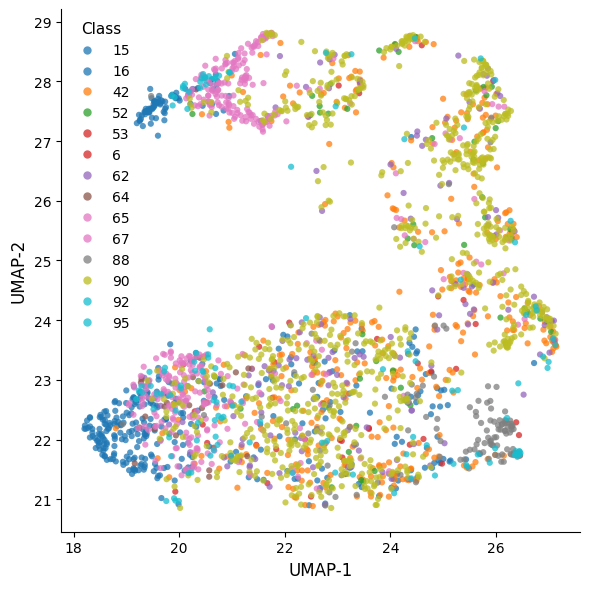

In [18]:
# ---------- Plot ----------
plt.figure(figsize=(6, 6))  # plus grand pour notebook

scatter = plt.scatter(
    low_dim_viz[:, 0],
    low_dim_viz[:, 1],
    c=df_y_train["target"].cat.codes,
    cmap="tab10",
    s=20,
    alpha=0.75,
    linewidths=0
)

plt.xlabel("UMAP-1", fontsize=12)
plt.ylabel("UMAP-2", fontsize=12)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# cleaner look
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ---------- Legend ----------
handles, _ = scatter.legend_elements()
labels = df_y_train["target"].cat.categories

plt.legend(
    handles,
    labels,
    title="Class",
    fontsize=10,
    title_fontsize=11,
    frameon=False,
    loc="best"
)

plt.tight_layout()
plt.show()

It is not great, we dont expect great performances.

In [19]:
# ---------- Plot ----------
fig, ax = plt.subplots(figsize=(4.0, 4.0), dpi=300)

scatter = ax.scatter(
    low_dim_viz[:, 0],
    low_dim_viz[:, 1],
    c=df_y_train["target"].cat.codes,
    cmap="tab10",
    s=8,
    alpha=0.8,
    linewidths=0
)

ax.set_xlabel("UMAP-1", fontsize=10)
ax.set_ylabel("UMAP-2", fontsize=10)

ax.tick_params(axis='both', which='major', labelsize=8)

# Optional: remove top/right spines (NeurIPS-friendly)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ---------- Legend ----------
handles, _ = scatter.legend_elements()
labels = df_y_train["target"].cat.categories
ax.legend(
    handles,
    labels,
    title="Class",
    fontsize=8,
    title_fontsize=9,
    loc="best",
    frameon=False
)

plt.tight_layout()

# ---------- Export ----------
#plt.savefig("umap_catch22.pdf", format="pdf", bbox_inches="tight")
plt.close()

In [86]:
# little neural network for tabular data
import torch
from sklearn.model_selection import train_test_split


class NNet(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.fc1 = torch.nn.Linear(input_dim, hidden_dim)
        self.relu = torch.nn.ReLU()
        self.fc2 = torch.nn.Linear(hidden_dim, hidden_dim)
    
    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out
    
    def fit(self, X, y, epochs=100, lr=0.001, test_size=0.2):
        
        # split
        X_train, X_val, y_train, y_val = train_test_split(
            X, y, test_size=test_size, random_state=42
        )

        train_loss_list = []
        val_loss_list = []

        criterion = torch.nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)

        X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
        y_train_tensor = torch.tensor(y_train, dtype=torch.long)

        X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)
        y_val_tensor = torch.tensor(y_val, dtype=torch.long)

        for epoch in range(epochs):

            # ---- TRAIN ----
            self.train()
            optimizer.zero_grad()

            outputs = self.forward(X_train_tensor)
            train_loss = criterion(outputs, y_train_tensor)

            train_loss.backward()
            optimizer.step()

            # ---- VALIDATION ----
            self.eval()
            with torch.no_grad():
                val_outputs = self.forward(X_val_tensor)
                val_loss = criterion(val_outputs, y_val_tensor)

            train_loss_list.append(train_loss.item())
            val_loss_list.append(val_loss.item())

        return train_loss_list, val_loss_list
    
    def predict(self, X):
        self.eval()
        X_tensor = torch.tensor(X.values, dtype=torch.float32)
        with torch.no_grad():
            outputs = self.forward(X_tensor)
        _, predicted = torch.max(outputs.data, 1)
        return predicted.numpy()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


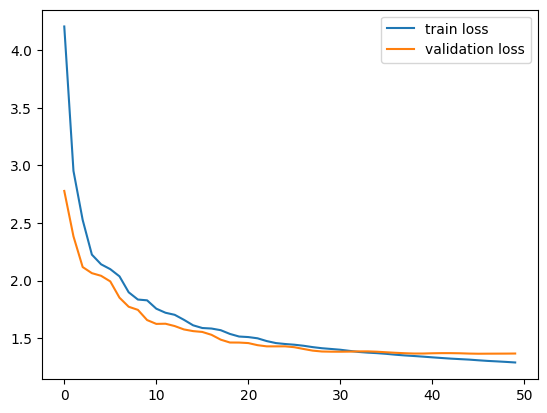

In [95]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report
import xgboost
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
encoded_target = le.fit_transform(df_y_train["target"])

logistic_regression = LogisticRegression(max_iter=100, random_state=SEED)
logistic_regression.fit(X_train_features, df_y_train["target"])

RF = RandomForestClassifier(random_state=SEED)
RF.fit(X_train_features, df_y_train["target"])

SVM = SVC(random_state=SEED, kernel="rbf", degree=6)
SVM.fit(X_train_features, df_y_train["target"])

XGB = xgboost.XGBClassifier(random_state=SEED, use_label_encoder=False, eval_metric="mlogloss")
XGB.fit(X_train_features, encoded_target)

neural_net = NNet(input_dim=X_train_features.shape[1], hidden_dim=64, output_dim=len(df_y_train["target"].cat.categories))
train_loss, val_loss = neural_net.fit(X_train_features, encoded_target, epochs=50, lr=0.01)

plt.plot(train_loss, label="train loss")
plt.plot(val_loss, label="validation loss")
plt.legend()
plt.show()

In [96]:
X_test_features = compute_catch22_features(X_test)
X_test_features = X_test_features.fillna(0)
# only droping one.. 1295

In [97]:
y_pred_logistic = logistic_regression.predict(X_test_features)
y_pred_RF = RF.predict(X_test_features)
y_pred_SVM = SVM.predict(X_test_features)
y_pred_XGB = XGB.predict(X_test_features)
y_pred_NNet = neural_net.predict(X_test_features)

In [98]:
df_y_test = tweak_and_convert_y(y_test)

# classification report 
print("Logistic Regression:")
print(classification_report(df_y_test["target"], y_pred_logistic))

Logistic Regression:
              precision    recall  f1-score   support

          15       0.36      0.23      0.28       124
          16       0.83      0.86      0.84       270
          42       0.49      0.32      0.39       382
          52       0.11      0.03      0.05        63
          53       0.00      0.00      0.00         7
           6       0.09      0.03      0.04        35
          62       0.23      0.04      0.07       153
          64       0.00      0.00      0.00        24
          65       0.60      0.83      0.70       313
          67       0.20      0.03      0.05        68
          88       0.76      0.76      0.76       121
          90       0.53      0.81      0.64       777
          92       0.38      0.16      0.22        77
          95       0.26      0.17      0.21        52

    accuracy                           0.56      2466
   macro avg       0.35      0.30      0.30      2466
weighted avg       0.51      0.56      0.51      2466



In [99]:
print("Random Forest:")
print(classification_report(df_y_test["target"], y_pred_RF))

Random Forest:
              precision    recall  f1-score   support

          15       0.71      0.28      0.40       124
          16       0.76      0.89      0.82       270
          42       0.59      0.38      0.46       382
          52       0.00      0.00      0.00        63
          53       0.00      0.00      0.00         7
           6       0.00      0.00      0.00        35
          62       0.00      0.00      0.00       153
          64       0.00      0.00      0.00        24
          65       0.63      0.87      0.73       313
          67       0.00      0.00      0.00        68
          88       0.86      0.78      0.82       121
          90       0.53      0.89      0.66       777
          92       0.91      0.13      0.23        77
          95       0.60      0.12      0.19        52

    accuracy                           0.60      2466
   macro avg       0.40      0.31      0.31      2466
weighted avg       0.54      0.60      0.54      2466



/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

In [100]:
print("Support Vector Machine:")
print(classification_report(df_y_test["target"], y_pred_SVM))

Support Vector Machine:
              precision    recall  f1-score   support

          15       0.91      0.08      0.15       124
          16       0.80      0.76      0.78       270
          42       0.61      0.16      0.26       382
          52       0.00      0.00      0.00        63
          53       0.00      0.00      0.00         7
           6       0.00      0.00      0.00        35
          62       0.00      0.00      0.00       153
          64       0.00      0.00      0.00        24
          65       0.51      0.89      0.65       313
          67       0.00      0.00      0.00        68
          88       0.79      0.64      0.70       121
          90       0.46      0.86      0.60       777
          92       0.00      0.00      0.00        77
          95       0.50      0.06      0.10        52

    accuracy                           0.53      2466
   macro avg       0.33      0.25      0.23      2466
weighted avg       0.49      0.53      0.44      2466



/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

In [101]:
print("XGBoost:")
print(classification_report(df_y_test["target"], le.inverse_transform(y_pred_XGB)))

XGBoost:
              precision    recall  f1-score   support

          15       0.59      0.40      0.48       124
          16       0.80      0.87      0.84       270
          42       0.54      0.44      0.48       382
          52       0.00      0.00      0.00        63
          53       1.00      0.29      0.44         7
           6       0.70      0.20      0.31        35
          62       0.37      0.10      0.15       153
          64       0.00      0.00      0.00        24
          65       0.69      0.87      0.77       313
          67       0.20      0.01      0.03        68
          88       0.87      0.84      0.86       121
          90       0.57      0.84      0.68       777
          92       0.63      0.34      0.44        77
          95       0.62      0.10      0.17        52

    accuracy                           0.62      2466
   macro avg       0.54      0.38      0.40      2466
weighted avg       0.58      0.62      0.58      2466



In [102]:
print("NNet:")
print(classification_report(df_y_test["target"], le.inverse_transform(y_pred_NNet)))

NNet:
              precision    recall  f1-score   support

          15       0.37      0.23      0.29       124
          16       0.83      0.85      0.84       270
          42       0.49      0.26      0.34       382
          52       0.00      0.00      0.00        63
          53       0.00      0.00      0.00         7
           6       0.00      0.00      0.00        35
          62       0.22      0.03      0.06       153
          64       0.50      0.04      0.08        24
          65       0.58      0.81      0.68       313
          67       0.00      0.00      0.00        68
          88       0.72      0.71      0.71       121
          90       0.49      0.81      0.61       777
          92       0.20      0.01      0.02        77
          95       0.23      0.10      0.14        52

    accuracy                           0.54      2466
   macro avg       0.33      0.28      0.27      2466
weighted avg       0.48      0.54      0.48      2466



/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

May need to fine-tune the hyperparameters but, here is a good baseline.

# Some fine-tuning of Hyperparameters